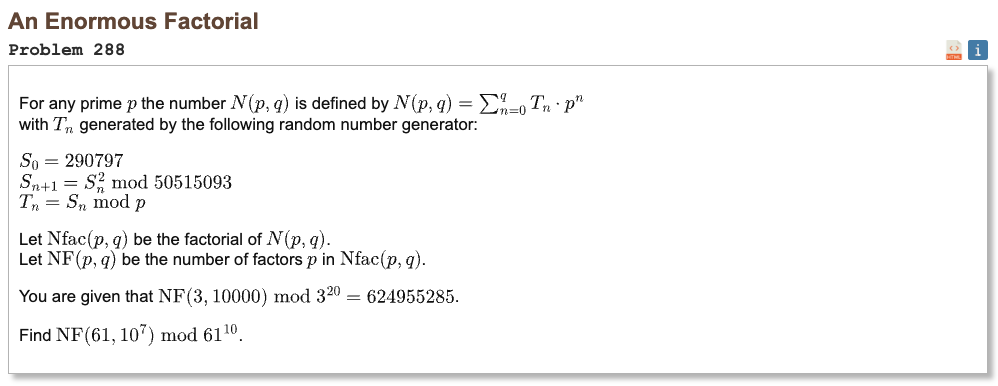

## Initial approach

* Write the very large number in base (p), so it becomes a sequence of digits.
* Instead of dealing with the full factorial, use the standard rule for counting how many times (p) divides a factorial, but apply it directly to those digits.
* Each digit adds a contribution that depends on how far along it appears in the sequence.
* Since you only need the result up to a certain power of (p), all digits far enough along contribute in the same way under that limit.
* This turns the problem from handling a huge factorial into simply processing the sequence once.
* Generate each digit from the given recurrence, add its contribution with the correct weight, and keep reducing the result modulo 61^10.
* A small example, like when (p = 3), works exactly the same way, showing that you never need to build the large number or compute its factorial directly.

In [1]:
def solve(p, q, e):
    mod = p ** e
    s = 290797
    total = 0
    coeff = 0
    power = 1
    full = sum(pow(p, i, mod) for i in range(e)) % mod

    for k in range(q + 1):
        t = s % p

        if k >= 1:
            if k < e:
                total = (total + t * coeff) % mod
            else:
                total = (total + t * full) % mod

        if k < e:
            coeff = (coeff + power) % mod
            power = (power * p) % mod

        s = (s * s) % 50515093

    return total

In [2]:
%%time
result = solve(61, 10**7, 10)
print("Result:", result)

Result: 605857431263981935
CPU times: user 1.39 s, sys: 10.1 ms, total: 1.4 s
Wall time: 1.4 s
